# Impacto da renda média sobre a mortalidade no Brasil

## Objetivo

Investigar a associação entre renda média estadual e taxas de mortalidade
no Brasil utilizando dados públicos do Sistema de Informações sobre
Mortalidade (SIM), PNAD Contínua e estimativas populacionais do IBGE.

Hipótese:

Estados com menor renda média apresentam maiores taxas de mortalidade.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

import statsmodels.api as sm
import statsmodels.formula.api as smf

#### Databases

In [2]:
PATH = '/home/tatiane/repositorios/brazil-health-data-project/data_pipeline/data/processed/'

sim = pd.read_parquet(f"{PATH}sim/standardization/sim_2018_2022.parquet")

popul = pd.read_parquet(f"{PATH}ibge_populacao/ibge_populacao2.parquet")

pnad = pd.read_parquet(f"{PATH}ibge_pnad_continua/ibge_pnad_continua.parquet")

ibge = pd.read_parquet(f"{PATH}ibge_codigos/02_standardization/dtb_br_2024_municipios.parquet")

### Construction of the analytical base

- Contagem de óbitos

In [3]:
sim = sim[["cod_mun_res", "ano"]]
#ibge = ibge[["cod_mun_comp", "cod_uf"]]
sim["cod_mun_res"] = pd.to_numeric(sim["cod_mun_res"], errors="coerce").astype("Int64")
sim["cod_uf"] = sim["cod_mun_res"] // 10000

In [4]:
obitos_uf = sim.groupby(["cod_uf", "ano"]).size().reset_index(name="obitos")

- População por UF

In [5]:
pop_uf = popul.merge(ibge[["cod_mun_comp", "cod_uf"]], left_on="cod_municipio", right_on="cod_mun_comp",how="left")

In [6]:
pop_cod_uf = (pop_uf.groupby(["cod_uf_x", "ano"])["populacao"].sum().reset_index())

In [7]:
pop_cod_uf = pop_cod_uf.rename(columns={"cod_uf_x" : "cod_uf"})

- Unindo com renda

In [8]:
obitos_uf["ano"] = obitos_uf["ano"].astype(str).str.extract(r"(\d{4})")[0]

In [9]:
obitos_uf["ano"] = obitos_uf["ano"].astype("Int64")
pop_cod_uf["ano"] = pop_cod_uf["ano"].astype("Int64")
pnad["ano"] = pnad["ano"].astype("Int64")

In [10]:
df = (obitos_uf.merge(pop_cod_uf, on=["cod_uf", "ano"]).merge(pnad, on=["cod_uf", "ano"]))

### Create mortality rate

In [11]:
df["taxa_mortalidade"] = (df["obitos"] / df["populacao"]) * 100000

### Exploratory analysis

- Estatísticas descritivas

In [12]:
df.describe()

,cod_uf,ano,obitos,populacao,renda_media,taxa_mortalidade
count,81.0,81.0,81.000000,81.0,81.000000,81.0
mean,29.111111,2019.0,52138.901235,15565375.728395,8355.123457,305.983308
std,12.860793,0.821584,65917.436781,18269309.260135,4724.313491,56.744147
min,11.0,2018.0,2779.000000,1153136.0,1815.000000,201.628945
25%,17.0,2018.0,16217.000000,5618788.0,3169.000000,265.404404
50%,27.0,2019.0,24763.000000,8078554.0,8841.000000,304.100105
75%,41.0,2020.0,64295.000000,18992588.0,11600.000000,339.058886
max,53.0,2020.0,349621.000000,92578666.0,22268.000000,495.667184


- Distribuição da renda

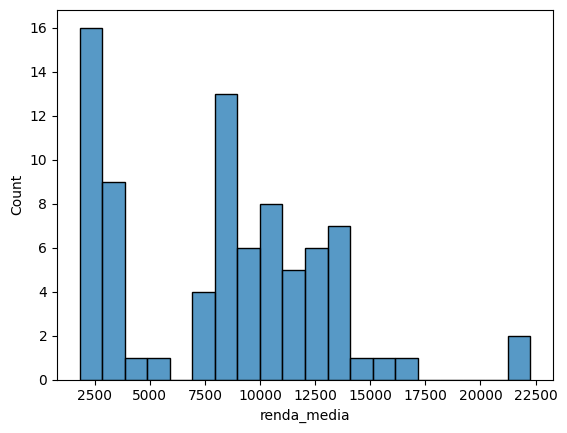

In [13]:
sns.histplot(data=df, x="renda_media", bins=20)
plt.show()

- Distribuição da mortalidade

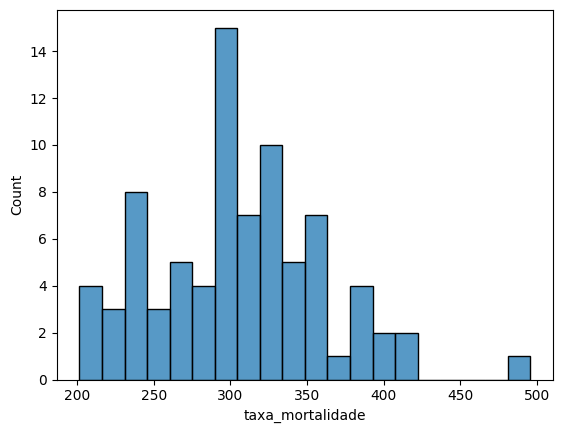

In [14]:
sns.histplot(data=df, x="taxa_mortalidade", bins=20)
plt.show()

### Correlation

In [15]:
corr, p = pearsonr(df["renda_media"], df["taxa_mortalidade"])
print(corr)
print(p)

-0.34193647416277073
0.0017820053263349759


### Main view

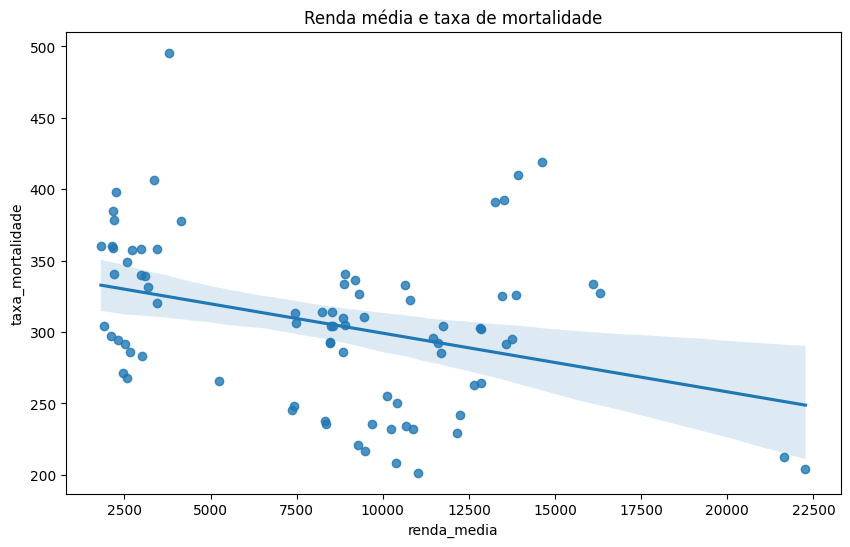

In [16]:
plt.figure(figsize=(10,6))
sns.regplot(data=df, x="renda_media", y="taxa_mortalidade")
plt.title("Renda média e taxa de mortalidade")
plt.show()

### Regression model

In [17]:
modelo = smf.ols("taxa_mortalidade ~ renda_media", data=df).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:       taxa_mortalidade   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.106
Method:                 Least Squares   F-statistic:                     10.46
Date:                Tue, 14 Jul 2026   Prob (F-statistic):            0.00178
Time:                        10:37:16   Log-Likelihood:                -436.52
No. Observations:                  81   AIC:                             877.0
Df Residuals:                      79   BIC:                             881.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     340.2980     12.171     27.961      

### More robust model

In [20]:
for col in df.columns:
    if str(df[col].dtype) == "Int64":
        df[col] = df[col].astype("int64")

In [22]:
modelo2 = smf.ols("taxa_mortalidade ~ renda_media + C(ano)", data=df).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:       taxa_mortalidade   R-squared:                       0.182
Model:                            OLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     5.711
Date:                Tue, 14 Jul 2026   Prob (F-statistic):            0.00139
Time:                        10:40:45   Log-Likelihood:                -433.42
No. Observations:                  81   AIC:                             874.8
Df Residuals:                      77   BIC:                             884.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        280.7121     27.194     10.

### State Rankings

In [25]:
ranking = (df.groupby("cod_uf").agg(renda_media=("renda_media", "mean"), taxa_mortalidade=("taxa_mortalidade", "mean"))
      .sort_values("taxa_mortalidade", ascending=False))

ranking.head(10)

,renda_media,taxa_mortalidade
cod_uf,,
33,10781.666667,441.472777
43,10046.666667,396.471543
26,6919.333333,353.66608
25,6649.333333,353.026553
35,12181.666667,346.195206
31,8042.666667,337.523522
41,10255.666667,336.634686
23,6518.333333,334.091999
22,5582.000000,326.643809


### Conclusion